In [1]:
import os
import math

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits
from sklearn import datasets
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as tt
from tqdm import tqdm


from IPython.display import clear_output
import time

In [2]:
class mydata_loader():
    """Scikit-Learn Digits dataset."""

    def __init__(self, x, mode='train', transforms=None):
        digits = x
        if mode == 'train':
            self.data = digits[0:25,...]
        elif mode == 'val':
            self.data = digits[26:50,...]
        else:
            self.data = digits[50:70,...]

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

**DISCLAIMER**

The presented code is not optimized, it serves an educational purpose. It is written for CPU, it uses only fully-connected networks and an extremely simplistic dataset. However, it contains all components that can help to understand how score matching works, and it should be rather easy to extend it to more sophisticated models. This code could be run almost on any laptop/PC, and it takes a couple of minutes top to get the result.

## Dataset: Digits

In this example, we go wild and use a dataset that is simpler than MNIST! We use a scipy dataset called Digits. It consists of ~1500 images of size 8x8, and each pixel can take values in $\{0, 1, \ldots, 16\}$.

The goal of using this dataset is that everyone can run it on a laptop, without any gpu etc.

In [3]:
folder = r"C:\Users\eskxpra\Downloads\score_matching\intro_dgm\dct_data"

files = [entry.name for entry in os.scandir(folder) if entry.is_file()]
# print(">"*100)
# print(files)
# print("<"*100)
test_d = np.load(os.path.join(folder,files[0]),allow_pickle=True)
# print(">"*100)
# print("shape of test_d",test_d.shape)
# print("<"*100)
test_abs = np.abs(test_d.reshape(-1,32,312))
# print(">"*100)
# print("shape of test_abs",test_abs.shape)
# print("<"*100)
abs = np.abs(test_abs)
# print(">"*100)
# print("shape of abs",abs.shape)
# print("<"*100)
# print(">"*100)
# print("abs example",abs[0,...])
# print("<"*100)

In [4]:
# import torchvision.transforms as tt
# transforms = tt.Lambda(lambda x: (x - np.mean(x)/np.std(x)))  # changing to [-1, 1]
# transforms = tt.Lambda(lambda x: 2. * (x / 17.) - 1.)  # changing to [-1, 1]

In [5]:
# class remove_mean_variance:
#     def __init__(self, mean=0.0, std=1.0):
#         self.mean = None
#         self.std = None

#     def __call__(self, tensor):
#         return (tensor - np.mean(tensor))/np.std(tensor)

#     def __repr__(self):
#         return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

In [6]:
# transforms = remove_mean_variance(0.0,1.0)
    
# from torchvision import transforms
# transforms = transforms.Compose([
#     transforms.ToTensor(),
#     remove_mean_variance(0.0,1.0)
# ])

In [7]:
train_data =mydata_loader(abs,mode='train', transforms=None)
val_data = mydata_loader(abs,mode='val', transforms=None)
test_data = mydata_loader(abs,mode='test', transforms=None)

training_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [8]:
# num_train_imgs = len(abs)
# print(">"*100)
# print("num_train_imgs",num_train_imgs)
# print("<"*100)
# batch_size = 32
# steps_per_epoch = num_train_imgs // batch_size # number of training steps per epoch

# # The indices of training images are shuffled for each epoch by permutation in JAX.
# # Assume that we have 7 samples in the dataset: [0, 1, 2, 3, 4, 5, 6] --> [3, 0, 2, 5, 4, 6, 1]
# perms = np.random.permutation(num_train_imgs)
# print(">"*100)
# print("shufflled perms",perms)
# print("<"*100)
# # After shuffling, sample indices are split into equally-sized groups to construct complete batches
# # If number of training samples is not divisible by batch size, last batch becomes incomplete.
# # The samples of that batch is removed: [3, 0, 2, 5, 4, 6, 1] --> [3, 0, 2, 5, 4, 6] --> [[3, 0], [2, 5], [4, 6]]
# perms = perms[:steps_per_epoch * batch_size]
# perms = perms.reshape((steps_per_epoch, batch_size))
# print(">"*100)
# print("nrof batches of perms",len(perms))
# print("<"*100)
# print(">"*100)
# print("nrof batches of perms",abs[perms[0]].reshape(-1,32*312).shape)
# print("<"*100)


In [9]:
# for perm in perms[0]:
#     print(">"*100)
#     print(abs[perm].shape)
#     print("<"*100)
    

## Score Matching

In [10]:
class ScoreMatching(nn.Module):
    def __init__(self, snet, alpha, sigma, eta, D, T):
        super(ScoreMatching, self).__init__()

        print('Score Matching by JT.')

        self.snet = snet
        
        # other hyperparams
        self.D = D
                
        self.sigma = sigma
        
        self.T = T
        
        self.alpha = alpha
        
        self.eta = eta
    
    def sample_base(self, x_1):
        # Uniform over [-1, 1]**D
        return 2. * torch.rand_like(x_1) - 1.
    
    def langevine_dynamics(self, x):
        for t in tqdm(range(self.T), desc="Sample generation via Langevin dynamics"):
            x = x + self.alpha * self.snet(x) + self.eta * torch.randn_like(x)
            if t % 10 == 0:
                clear_output(wait=True) 
                plt.imshow(np.abs(np.squeeze(x[0,:,...].detach().numpy())), cmap='gray')
                plt.title(f"Step {t}")
                plt.axis('off')
                plt.show()
                time.sleep(0.5)
        return x

    def forward(self, x, reduction='mean'):
        # =====Score Matching
        # sample noise
        epsilon = torch.randn_like(x)
        
        # =====
        # calculate the noisy data
        tilde_x = x + self.sigma * epsilon

        # =====
        # calculate the score model
        tilde_x_w_ch = torch.unsqueeze(tilde_x, 1)
        s = self.snet(tilde_x_w_ch)
        
        # =====LOSS: the Score Matching Loss
        SM_loss = (1. / (2. * self.sigma)) * ((s + epsilon)**2.).sum(-1) # in order to keep the Langevine dynamics unchanged, we do not use \tilde{s} = -sigma * s but we use \tilde{s} = sigma * s
        
        # Final LOSS
        if reduction == 'sum':
            loss = SM_loss.sum()
        else:
            loss = SM_loss.mean()

        return loss

    def sample(self,  batch_size=64):
        # sample x_0
        x = self.sample_base(torch.empty(batch_size,1, 32,312))
        
        # run langevine dynamics
        x = self.langevine_dynamics(x)
        
        x = torch.tanh(x)
        return x

## Evaluation and Training functions

**Evaluation step, sampling and curve plotting**

In [11]:
def evaluation(test_loader, name=None, model_best=None, epoch=None):
    # EVALUATION
    if model_best is None:
        # load best performing model
        model_best = torch.load(name + '.model')

    model_best.eval()
    loss = 0.
    N = 0.
    for indx_batch, test_batch in enumerate(test_loader):
        loss_t = model_best.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N

    if epoch is None:
        print(f'FINAL LOSS: nll={loss}')
    else:
        print(f'Epoch: {epoch}, val nll={loss}')

    return loss


def samples_real(name, test_loader):
    # REAL-------
    num_x = 32
    num_y = 312
    x = next(iter(test_loader)).detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.abs(np.squeeze(x[i,:,...].detach().numpy())) #np.reshape(x[i], (32, 312))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.savefig(name+'_real_images.pdf', bbox_inches='tight')
    plt.close()


def samples_generated(name, data_loader, extra_name='', T=None):
    # GENERATIONS-------
    model_best = torch.load(name + '.model')
    model_best.eval()
    
    if T is not None:
        model_best.T = T

    num_x = 4
    num_y = 4
    x = model_best.sample(batch_size=32)
    x = x.detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.abs(np.squeeze(x[i,:,...].detach().numpy())) #np.reshape(x[i], (32, 312))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.savefig(name + '_generated_images' + extra_name + '.pdf', bbox_inches='tight')
    plt.close()

def plot_curve(name, nll_val):
    plt.plot(np.arange(len(nll_val)), nll_val, linewidth='3')
    plt.xlabel('epochs')
    plt.ylabel('score matching loss')
    plt.savefig(name + '_sm_val_curve.pdf', bbox_inches='tight')
    plt.close()

**Training step**

In [12]:
def training(name, max_patience, num_epochs, model, optimizer, training_loader, val_loader):
    nll_val = []
    best_nll = 1000.
    patience = 0

    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            loss = model.forward(batch)

            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Validation
        loss_val = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_val)  # save for plotting

        if e == 0:
            print('saved!')
            torch.save(model, name + '.model')
            best_nll = loss_val
        else:
            if loss_val < best_nll:
                print('saved!')
                torch.save(model, name + '.model')
                best_nll = loss_val
                patience = 0

                samples_generated(name, val_loader, extra_name="_epoch_" + str(e))
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    nll_val = np.asarray(nll_val)

    return nll_val

## Experiments

**Initialize datasets**

**Hyperparameters**

In [13]:
D = 32*312   # input dimension

M =  312  # the number of neurons in scale (s) and translation (t) nets

alpha = 0.1

sigma = 0.1

eta = 0.05

T = 100

lr = 1e-4 # learning rate
num_epochs = 50 # max. number of epochs
max_patience = 20 # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

**Creating a folder for results**

In [14]:
name = 'sm' + '_' + str(T)
result_dir = os.path.join(r"C:\Users\eskxpra\Downloads\score_matching\intro_dgm",'results/' + name + '/')
if not (os.path.exists(result_dir)):
    os.mkdir(result_dir)

In [15]:
import torch.nn as nn


def kcnn():
    nF = 16
    ks1 = 4
    stride = 1
    ps = 2
    rxports = 32
    symbols = 2
    taps = 312
    layers = 1
    model = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.Conv2d(in_channels=nF, out_channels=nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(1,1), stride=stride),
        nn.Conv2d(in_channels=nF, out_channels=2*nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.Conv2d(in_channels=2*nF, out_channels=2*nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(1,1), stride=stride),
        nn.Conv2d(in_channels=2*nF, out_channels=4*nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.Conv2d(in_channels=4*nF, out_channels=2*nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.ConvTranspose2d(in_channels=2*nF, out_channels=nF, kernel_size=3, stride=stride, padding=1),
        nn.Conv2d(in_channels=nF, out_channels=4*nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.Conv2d(in_channels=4*nF, out_channels=2*nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.ConvTranspose2d(in_channels=2*nF, out_channels=nF, kernel_size=3, stride=stride, padding=1),
        nn.Conv2d(in_channels=nF, out_channels=nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.Conv2d(in_channels=nF, out_channels=nF, kernel_size=ks1, padding='same'),
        nn.ReLU(),
        nn.Conv2d(in_channels=nF, out_channels=1, kernel_size=ks1, padding='same'),
    )
    return model
        
           

In [16]:
snet = nn.Sequential(nn.Linear(D, M), nn.SELU(),
                     nn.Linear(M, M), nn.SELU(),
                     nn.Linear(M, M), nn.SELU(),
                     nn.Linear(M, D), nn.ReLU())

# Eventually, we initialize the full model
model = ScoreMatching(snet=snet, alpha=alpha, sigma=sigma, eta=eta, T=T, D=D)

Score Matching by JT.


**Initializing the model**

In [17]:
# snet = nn.Sequential(nn.Linear(D, M), nn.SELU(),
#                      nn.Linear(M, M), nn.SELU(),
#                      nn.Linear(M, M), nn.SELU(),
#                      nn.Linear(M, D), nn.Hardtanh(min_val=-4., max_val=4.))
from IPython.display import display
from torchinfo import summary 
snet = kcnn()
display(summary(snet, input_size=(32,1,32,312)) )
# # Eventually, we initialize the full model
model = ScoreMatching(snet=snet, alpha=alpha, sigma=sigma, eta=eta, T=T, D=D)
# print(">"*100)
# for param in model.parameters():
#     print(param.shape)
# print("<"*100)

c:\Users\eskxpra\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\nn\modules\conv.py:459: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\Convolution.cpp:896.)
  return F.conv2d(input, weight, bias, self.stride,


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 1, 32, 312]          --
├─Conv2d: 1-1                            [32, 16, 32, 312]         272
├─ReLU: 1-2                              [32, 16, 32, 312]         --
├─Conv2d: 1-3                            [32, 16, 32, 312]         4,112
├─ReLU: 1-4                              [32, 16, 32, 312]         --
├─MaxPool2d: 1-5                         [32, 16, 32, 312]         --
├─Conv2d: 1-6                            [32, 32, 32, 312]         8,224
├─ReLU: 1-7                              [32, 32, 32, 312]         --
├─Conv2d: 1-8                            [32, 32, 32, 312]         16,416
├─ReLU: 1-9                              [32, 32, 32, 312]         --
├─MaxPool2d: 1-10                        [32, 32, 32, 312]         --
├─Conv2d: 1-11                           [32, 64, 32, 312]         32,832
├─ReLU: 1-12                             [32, 64, 32, 312]         --


Score Matching by JT.


**Optimizer - here we use Adamax**

In [18]:
# OPTIMIZER
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad == True], lr=lr)

**Training loop**

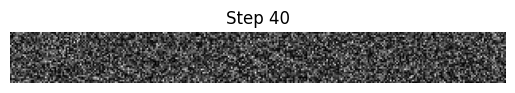

Sample generation via Langevin dynamics:  44%|████▍     | 44/100 [01:47<02:16,  2.44s/it]


KeyboardInterrupt: 

In [19]:
# Training procedure
nll_val = training(name=result_dir + name, max_patience=max_patience, num_epochs=num_epochs, model=model, optimizer=optimizer,
                       training_loader=training_loader, val_loader=val_loader)

**The final evaluation**

In [ ]:
test_loss = evaluation(name=result_dir + name, test_loader=test_loader)
f = open(result_dir + name + '_test_loss.txt', "w")
f.write(str(test_loss))
f.close()

samples_real(result_dir + name, test_loader)
samples_generated(result_dir + name, test_loader, extra_name='FINAL')

plot_curve(result_dir + name, nll_val)